In [10]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

df = pl.read_parquet("out/*.parquet")

df

iterations,invalidation_method,page_number,compressed_size,uncompressed_size,compression_time,decompression_time,version,trace,alg,iter,inv
i64,i64,i64,i64,i64,i64,i64,i32,str,str,str,str
4,1,1,1300,4096,30405,16100,1,"""work-small""","""WKdm""","""4""","""clflush"""
4,1,2,2008,4096,16147,12140,1,"""work-small""","""WKdm""","""4""","""clflush"""
4,1,3,1192,4096,11478,7821,1,"""work-small""","""WKdm""","""4""","""clflush"""
4,1,4,1180,4096,9200,7192,1,"""work-small""","""WKdm""","""4""","""clflush"""
4,1,5,2764,4096,8692,6308,1,"""work-small""","""WKdm""","""4""","""clflush"""
…,…,…,…,…,…,…,…,…,…,…,…
4,0,455,1161,4096,23905,8095,1,"""work-small""","""zstd""","""4""","""none"""
4,0,456,939,4096,23151,10986,1,"""work-small""","""zstd""","""4""","""none"""
4,0,457,1553,4096,24037,9791,1,"""work-small""","""zstd""","""4""","""none"""


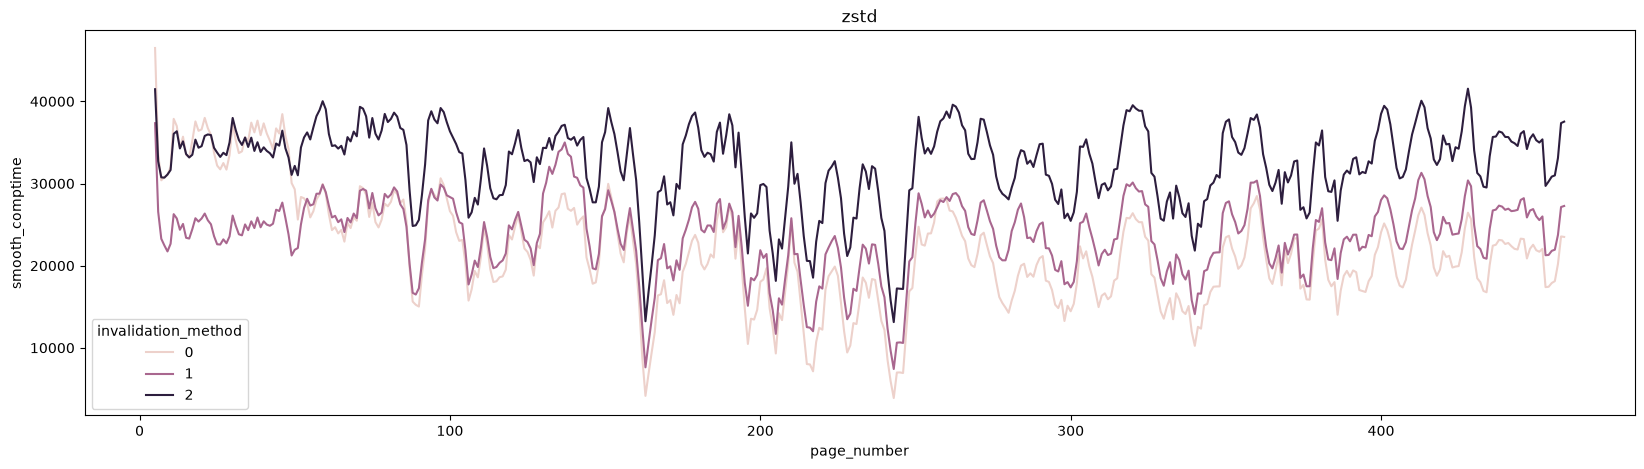

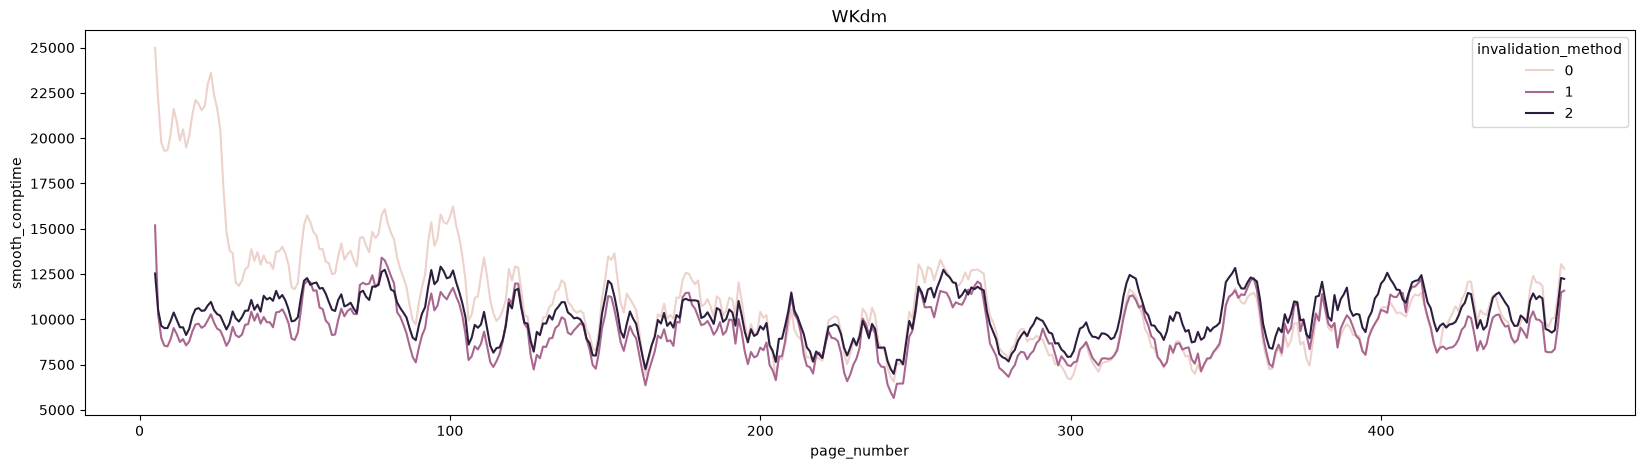

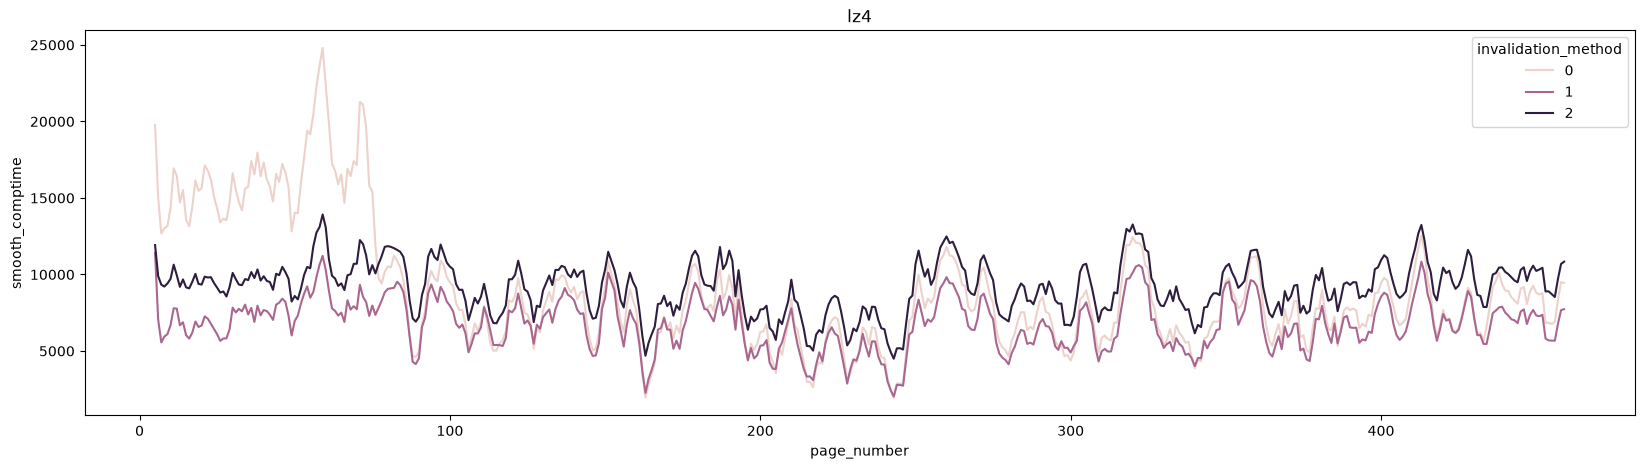

In [13]:
df1 = df.with_columns(
    pl.col("compression_time")
    .rolling_mean(window_size=5)
    .over(["alg", "invalidation_method"])
    .alias("smooth_comptime")
)

for alg in df["alg"].unique().to_list():
    plt.figure(figsize=(20,5))
    ax = sns.lineplot(
        df1.filter(pl.col("alg") == alg),
        x="page_number",
        y="smooth_comptime",
        hue="invalidation_method"
    )
    ax.set_title(alg)